### Assignment 01
### 258828H

#### Question 01

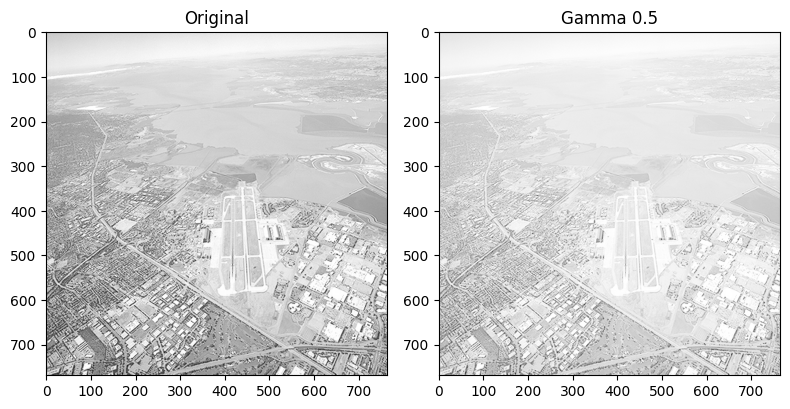

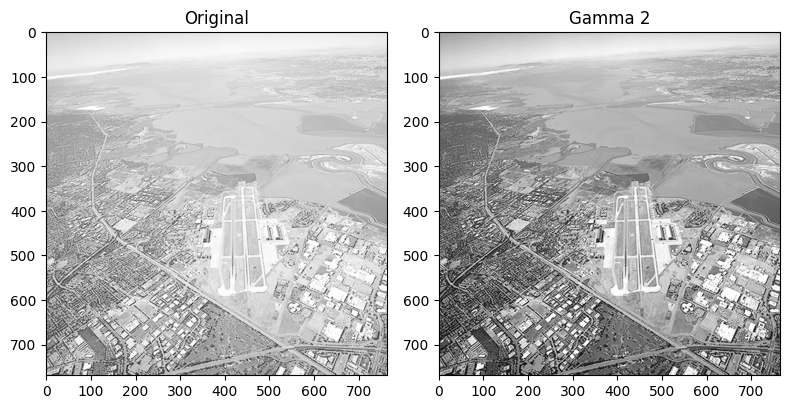

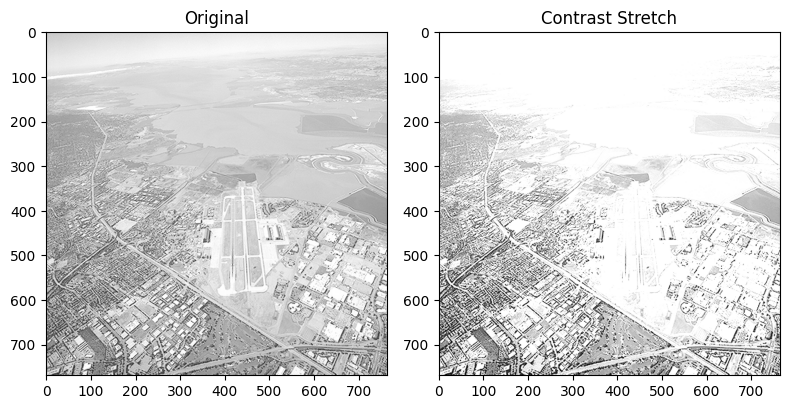

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs('outputs', exist_ok=True)

img = cv2.imread('images/runway.png', 0)

img = img / 255.0

# (a)
gamma_05 = np.power(img, 0.5)
cv2.imwrite('outputs/q1_gamma_05.png', (gamma_05*255).astype('uint8'))

# --------- COMPARISON 1 (Original vs Gamma 0.5) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Gamma 0.5')
plt.imshow(gamma_05, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_a.png')
plt.show()

# (b)
gamma_2 = np.power(img, 2)
cv2.imwrite('outputs/q1_gamma_2.png', (gamma_2*255).astype('uint8'))

# --------- COMPARISON 2 (Original vs Gamma 2) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Gamma 2')
plt.imshow(gamma_2, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_b.png')
plt.show()

# (c)
r1, r2 = 0.2, 0.8
cs = np.clip((img - r1)/(r2 - r1), 0, 1)
cv2.imwrite('outputs/q1_contrast.png', (cs*255).astype('uint8'))

# --------- COMPARISON 3 (Original vs Contrast) ----------
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title('Contrast Stretch')
plt.imshow(cs, cmap='gray')

plt.tight_layout()
plt.savefig('outputs/q1_compare_c.png')
plt.show()

#### Question 02

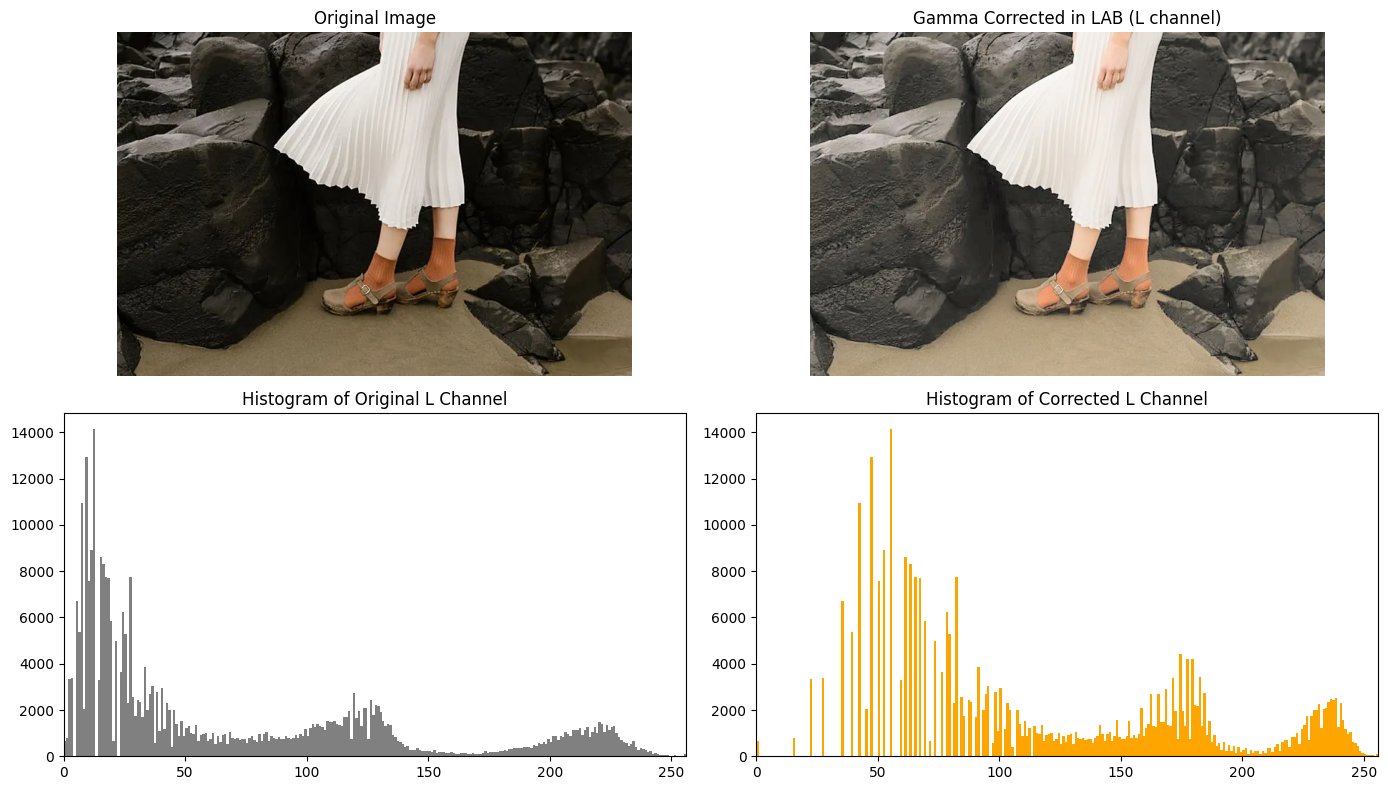

In [4]:
img_bgr = cv2.imread('images/Image for gamma correction.webp')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# (a)
lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
L, a, b = cv2.split(lab)

gamma = 0.5
L_norm = L / 255.0
L_gamma = np.power(L_norm, gamma)
L_gamma = np.clip(L_gamma * 255, 0, 255).astype(np.uint8)

lab_gamma = cv2.merge([L_gamma, a, b])
img_lab_gamma = cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2RGB)

cv2.imwrite('outputs/q2_original.png', cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite('outputs/q2_lab_gamma.png', cv2.cvtColor(img_lab_gamma, cv2.COLOR_RGB2BGR))

# (b)
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title('Gamma Corrected in LAB (L channel)')
plt.imshow(img_lab_gamma)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Histogram of Original L Channel')
plt.hist(L.ravel(), bins=256, range=(0, 256), color='gray')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title('Histogram of Corrected L Channel')
plt.hist(L_gamma.ravel(), bins=256, range=(0, 256), color='orange')
plt.xlim([0, 256])

plt.tight_layout()
plt.savefig('outputs/q2_lab_gamma_comparison.png')
plt.show()